# Let's try some **regression**!!

## Simple Regression

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import src.machine_learning as ML


class GlyphClassifier(nn.Module):
    def __init__(self, resolution):
        super(GlyphClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * resolution[0]//8 * resolution[1]//8, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
 
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten the output
        x = self.classifier(x)
        return x

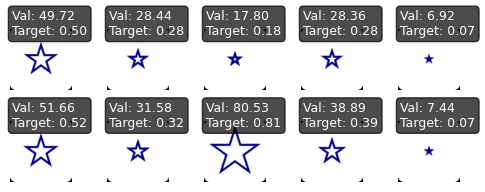

Displaying first 10 images from batch of 10


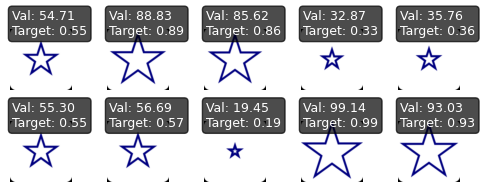

In [3]:
# Getting the dataset
dataset_file = 'data/simple-star.zip'
train_dataset = ML.GlyphDataset(dataset_file, resize=(128,128), split = "train",mode="regression")
test_dataset = ML.GlyphDataset(dataset_file, resize=(128,128),split = 'test',mode='regression')
train_dataset.show()

# Assign the loaders 

train_loader = ML.create_loader(train_dataset, batch_size=64, shuffle = True)
test_loader = ML.create_loader(test_dataset, batch_size=64, shuffle = False)
ML.visualize_loader(train_loader,max_images=10,nrow=5)


cuda
Epoch 1/50 - Loss: 0.2671
Epoch 2/50 - Loss: 0.1421
Epoch 3/50 - Loss: 0.1100
Epoch 4/50 - Loss: 0.0802
Epoch 5/50 - Loss: 0.0763
Epoch 6/50 - Loss: 0.0899
Epoch 7/50 - Loss: 0.0690
Epoch 8/50 - Loss: 0.0617
Epoch 9/50 - Loss: 0.0030
Epoch 10/50 - Loss: 0.0075
Epoch 11/50 - Loss: 0.0028
Epoch 12/50 - Loss: 0.0015
Epoch 13/50 - Loss: 0.0004
Epoch 14/50 - Loss: 0.0004
Epoch 15/50 - Loss: 0.0003
Epoch 16/50 - Loss: 0.0001
Epoch 17/50 - Loss: 0.0000
Epoch 18/50 - Loss: 0.0001
Epoch 19/50 - Loss: 0.0000
Epoch 20/50 - Loss: 0.0000
Epoch 21/50 - Loss: 0.0001
Epoch 22/50 - Loss: 0.0001
Epoch 23/50 - Loss: 0.0000
Epoch 24/50 - Loss: 0.0000
Epoch 25/50 - Loss: 0.0000
Epoch 26/50 - Loss: 0.0000
Epoch 27/50 - Loss: 0.0000
Epoch 28/50 - Loss: 0.0000
Epoch 29/50 - Loss: 0.0000
Epoch 30/50 - Loss: 0.0000
Epoch 31/50 - Loss: 0.0000
Epoch 32/50 - Loss: 0.0000
Epoch 33/50 - Loss: 0.0000
Epoch 34/50 - Loss: 0.0000
Epoch 35/50 - Loss: 0.0000
Epoch 36/50 - Loss: 0.0000
Epoch 37/50 - Loss: 0.0000
Epoch

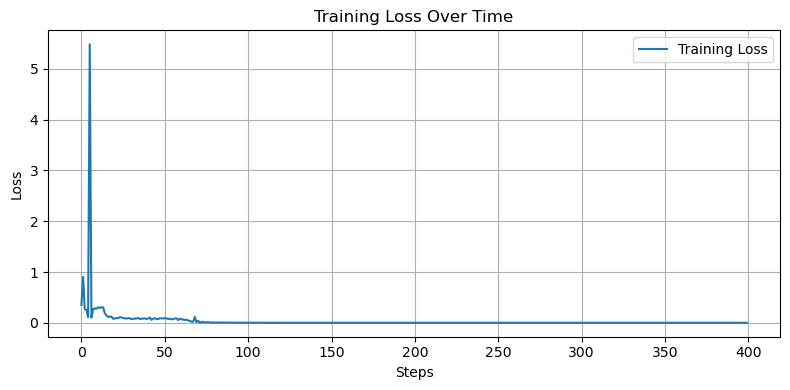

In [ ]:
import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = GlyphClassifier(resolution=(128, 128)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 20
losses = []

for epoch in range(num_epochs):
    model.train()
    for images, labels, _ in train_loader:
        images = images.to(device)
        labels = labels.to(device)\
        
        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels.squeeze())
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {losses[-1]:.4f}")

    
ML.plot_training_loss(losses)

In [12]:
import numpy as np 

model.eval()
predictions = []
ground_truths = []

with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images).squeeze()
        predictions.extend(outputs.cpu().numpy())
        ground_truths.extend(labels.cpu().numpy())

predictions = np.array(predictions)
ground_truths = np.array(ground_truths)

mse = np.mean((predictions - ground_truths)**2)
mae = np.mean(np.abs(predictions - ground_truths))

print(f"Regression MSE: {mse:.4f}")
print(f"Regression MAE: {mae:.4f}")


Regression MSE: 0.1199
Regression MAE: 0.2802


## Binned Regression

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import src.machine_learning as ML

class GlyphClassifier(nn.Module):
    def __init__(self, NUM_classes, resolution):
        super(GlyphClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * resolution[0]//4 * resolution[1]//4, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten the output
        x = self.classifier(x)
        return x

In [ ]:
import numpy as np
import src.machine_learning as ML
NUM_bin = 10 #Number of bins can be set here

# Getting the dataset
dataset_file = 'data/simple-star.zip'
train_dataset = ML.GlyphDataset(dataset_file, resize=(64,64), split = "train",bins=NUM_bin, mode='regression')
test_dataset = ML.GlyphDataset(dataset_file, resize=(64,64),split = 'test', bins=NUM_bin, mode='regression')
train_dataset.show(num=10)

# Assign the loaders 

train_loader = ML.create_loader(train_dataset, batch_size=64, shuffle = True)
test_loader = ML.create_loader(test_dataset, batch_size=64, shuffle = False)
ML.visualize_loader(train_loader,max_images=10,nrow=5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


In [ ]:
import matplotlib.pyplot as plt
model = GlyphClassifier(NUM_bin, resolution=(64, 64)).to(device)
criterion = nn.CrossEntropyLoss()  # Same as classification, still valid for bin prediction
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# -- Training Loop --
num_epochs = 10
losses = []

for epoch in range(num_epochs):
    model.train()
    for images, labels, _ in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print(f"Epoch {epoch + 1}/{num_epochs} - Last Batch Loss: {losses[-1]:.4f}")

ML.plot_training_loss(losses)

# -- Evaluation Loop --
all_true_labels = []
all_predicted_labels = []
correct_predictions = 0
total_samples = 0

model.eval()
with torch.no_grad():
    for images, labels, _ in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted_labels = torch.max(outputs.data, 1)

        total_samples += labels.size(0)
        correct_predictions += (predicted_labels == labels).sum().item()
        all_true_labels.extend(labels.cpu().numpy())
        all_predicted_labels.extend(predicted_labels.cpu().numpy())

accuracy = 100 * correct_predictions / total_samples
print(f'\n--- Evaluation Results ---')
print(f'Total Test Samples: {total_samples}')
print(f'Correct Predictions: {correct_predictions}')
print(f'Accuracy on the test set: {accuracy:.2f}%')
print(f'--------------------------')

# -- Additional Metric: Mean Absolute Bin Error --
all_true_labels_np = np.array(all_true_labels)
all_predicted_labels_np = np.array(all_predicted_labels)
mean_absolute_bin_error = np.mean(np.abs(all_true_labels_np - all_predicted_labels_np))
print(f"Mean Absolute Bin Error (MABE): {mean_absolute_bin_error:.4f}")

# -- Confusion Matrix --
class_names = [f'Bin {i}' for i in range(NUM_bin)]
print("\nGenerating Confusion Matrix...")
ML.plot_confusion_matrix(
    y_true=all_true_labels,
    y_pred=all_predicted_labels,
    classes=class_names,
    normalize=False
)
plt.show()

# -- Show Incorrect Predictions --
ML.show_incorrect_predictions(
    model, test_loader, num_classes=NUM_bin, max_display=10, device=device
)